In [1]:
import sys
import numpy as np
import torch 
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
# get UMAP
import umap

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

2.1.0.dev20230321+cu117
11.7
Tesla V100-PCIE-16GB
2.1.0.dev20230321+cu117
11.7
Tesla V100-PCIE-16GB


<module 'factor_model' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py'>

In [2]:
leaflet_repo = '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-binomial-mix/'
sys.path.append(leaflet_repo)
import load_cluster_data
from betabinomo_mix_singlecells import *

### Settings and Load data

In [3]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cuda


In [4]:
input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/'

cell_types = ['Brain_Non-Myeloid_brain_pericyte','Brain_Non-Myeloid_oligodendrocyte_precursor_cell','Brain_Non-Myeloid_endothelial_cell','Brain_Non-Myeloid_oligodendrocyte',
 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage',
 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte']

#ignoring Bergmann_glial_cell since very few cells

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, celltypes=cell_types, has_genes="yes") 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/
Finished reading in data from folder ...
Looking at only specific cell types ...['Brain_Non-Myeloid_brain_pericyte', 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell', 'Brain_Non-Myeloid_endothelial_cell', 'Brain_Non-Myeloid_oligodendrocyte', 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage', 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte']
['Brain_Non-Myeloid_brain_pericyte'
 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell'
 'Brain_Non-Myeloid_endothelial_cell' 'Brain_Non-Myeloid_oligodendrocyte'
 'Brain_Non-Myeloid_neuron' 'Brain_Myeloid_macrophage'
 'Brain_Myeloid_microglial_cell' 'Brain_Non-Myeloid_astrocyte']
7816
16190
The maximum junction count was initially:  150346
80
The maximum junction count is now:  4982
                                             cell_id  Cluster  Cluster_Counts  \
0  A14-MAA000581-3_10_M-1-1_Brain_Non-M

In [5]:
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

The number of cells going into training data is:
7816
7816


/gpfs/commons/home/kisaev/Leaflet-private/src/beta-binomial-mix/betabinomo_mix_singlecells.py:333: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount_lookup = torch.sparse_coo_tensor(


In [6]:
simple_data = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

### Get ready for model training 

In [7]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

In [8]:
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [9]:
indices_counts = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(final_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = final_data['cell_id_index'].max() + 1
num_junctions_counts = final_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [10]:
# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

In [11]:
# how many zeroes in the data compared to total number of values
perc_nonzero = cluster_counts.nnz / (cluster_counts.shape[0] * cluster_counts.shape[1])
print("The percentage of missing values in the intron counts matrix is: ", 1-perc_nonzero)

The percentage of missing values in the intron counts matrix is:  0.915291053255577


## Evaluate performance on imputation/masking task

In [12]:
# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations')
import masking
from masking import *

# import reload 
from importlib import reload
reload(masking)

<module 'masking' from '/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py'>

In [13]:
#1. get masked matrix using intron cluster counts for this mouse brain data 
masking_percs = [0.1]
masks_list = []

# get masked matrix for each masking percentage

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting masked matrix for each masking percentage")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for perc_mask in masking_percs:
    print("The masking percentage is: " + str(perc_mask))
    masked_matrix = generate_mask(cluster_counts, mask_percentage = perc_mask)
    masks_list.append(masked_matrix)

#2. get junction and intron cluster count matrices with masked values 
masked_counts = []

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting junction and intron cluster count matrices with masked values")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for i in range(len(masking_percs)):
    print("The masking percentage is: " + str(masking_percs[i]))
    masked_junction_counts, masked_intron_clusts = apply_mask(junc_counts, cluster_counts, masks_list[i])
    # appent masked junction and intron cluster counts to list
    masked_counts.append((masked_junction_counts, masked_intron_clusts))

#3. get input files for factor model (junction and intron cluster sparse tensor)
model_input_files = [] 

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting input files for factor model")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for i in range(len(masking_percs)):
    print("The masking percentage is: " + str(masking_percs[i]))
    masked_junction_counts, masked_intron_clusts = masked_counts[i]
    # get y_tensor and total_counts_tensor via prep_model_input function
    y_tensor, total_counts_tensor = prep_model_input(masked_junction_counts, masked_intron_clusts)
    # append to model_input_files list
    model_input_files.append((y_tensor, total_counts_tensor))

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Getting masked matrix for each masking percentage
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
The masking percentage is: 0.1
Number of entries (junction-cell pairs) masked:  1054635.0
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Getting junction and intron cluster count matrices with masked values
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
The masking percentage is: 0.1
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Getting input files for factor model
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
The masking percentage is: 0.1


/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:130: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:245.)
  indices = torch.tensor(np.nonzero(masked_intron_clusts), dtype=torch.long)


In [14]:
# Now can run factor model on masked data
Ks = [20, 100, 150, 200, 250, 350, 500]
all_Ks_results = {}

# define list of seeds 
seeds = [420, 4003]

for k in Ks:
    
    print("------------------------------------------------")
    print("Running factor model for K = " + str(k))
    print("------------------------------------------------")
    
    # now also iterate over masking percentages 
    for i in range(len(masking_percs)):
        print("The masking percentage is: " + str(masking_percs[i]))
        y_tensor, total_counts_tensor = model_input_files[i]
        # run factor model
        masked_results = factor_model.main(y_tensor, total_counts_tensor, num_initializations=2, use_global_prior=True, K=k, seeds=seeds,loss_plot=False, num_epochs=500, lr = 0.01, save_to_file = False)
        # save results to dictionary
        all_Ks_results[(k, masking_percs[i])] = masked_results

------------------------------------------------
Running factor model for K = 20
------------------------------------------------
The masking percentage is: 0.1
Using prior for a and b per junction to model average behaviour!
Initialization 1 with seed 420
Define the guide
Fit the model
Epoch 0, Loss: 230364910.10030097
Epoch 10, Loss: 216603545.466438
Epoch 20, Loss: 203970259.73674673
Epoch 30, Loss: 192358453.7821348
Epoch 40, Loss: 181773296.04672706
Epoch 50, Loss: 172098435.46774966
Epoch 60, Loss: 163228682.5032427
Epoch 70, Loss: 155104156.10688105
Epoch 80, Loss: 147516298.57226148
Epoch 90, Loss: 140529233.2412228
Epoch 100, Loss: 133892924.39341524
Epoch 110, Loss: 127707683.34992668
Epoch 120, Loss: 121602027.16376367
Epoch 130, Loss: 115814305.86353359
Epoch 140, Loss: 110375305.14663681
Epoch 150, Loss: 105231716.08759755
Epoch 160, Loss: 100175340.22184199
Epoch 170, Loss: 95624586.7998493
Epoch 180, Loss: 91483619.24999088
Epoch 190, Loss: 87663027.50407857
Epoch 200, L

In [15]:
# Get pearson correlation and l1 error between true and inferred parameters (PSI)
masked_perf = []

for k in Ks:
    for perc_mask in masking_percs:
        print("Calculating performance for K = " + str(k) + " and masking percentage = " + str(perc_mask))
        masked_results = all_Ks_results[(k, perc_mask)]        
        for res in masked_results:
            # get seed that was used 
            seed = res['seed']

            # get latent variables
            psi = res['latent_vars']["psi"] # psi is the probability of a junction being used in a cluster
            assign_post=res['latent_vars']["assign"]

            # get K 
            K = psi.shape[0]
            J = psi.shape[1]

            # get scores 
            mask_matrix_used = masks_list[i]
            l1, r, l2 = evaluate_model(junc_counts.toarray(), cluster_counts.toarray(), psi, assign_post, mask_matrix_used)

            # get num epochs trained for 
            nepoch = len(res["losses"])

            # save to list 
            masked_perf.append([seed, l1, r, l2, K, perc_mask, J, nepoch])

# make masked_perf a dataframe 
masked_perf_df = pd.DataFrame(masked_perf, columns=["seed", "l1", "r", "l2", "K",  "perc_masked" , "J", "num_epochs"])

Calculating performance for K = 20 and masking percentage = 0.1


/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:178: RuntimeWarning: invalid value encountered in divide
  true_psi = true_juncs / true_clusts


L1 error:  0.1710455962597872
Spearman correlation:  0.7172371170899147
L2 error:  0.06795838340927919
L1 error:  0.17423987145235814
Spearman correlation:  0.7086121581527303
L2 error:  0.06987467367815524
Calculating performance for K = 100 and masking percentage = 0.1
L1 error:  0.16738239735514412
Spearman correlation:  0.7221142527822138
L2 error:  0.06698149271034873
L1 error:  0.16824777382233208
Spearman correlation:  0.7209559859107681
L2 error:  0.06735069387174336
Calculating performance for K = 150 and masking percentage = 0.1
L1 error:  0.16743823392919202
Spearman correlation:  0.7219461909508726
L2 error:  0.06708847963498282
L1 error:  0.16710404515351332
Spearman correlation:  0.7224282250464201
L2 error:  0.06696149414982584
Calculating performance for K = 200 and masking percentage = 0.1
L1 error:  0.16708593920879136
Spearman correlation:  0.7226574218095035
L2 error:  0.06682277770324917
L1 error:  0.16647733278892796
Spearman correlation:  0.7235348836645721
L2 er

#### Make plots 

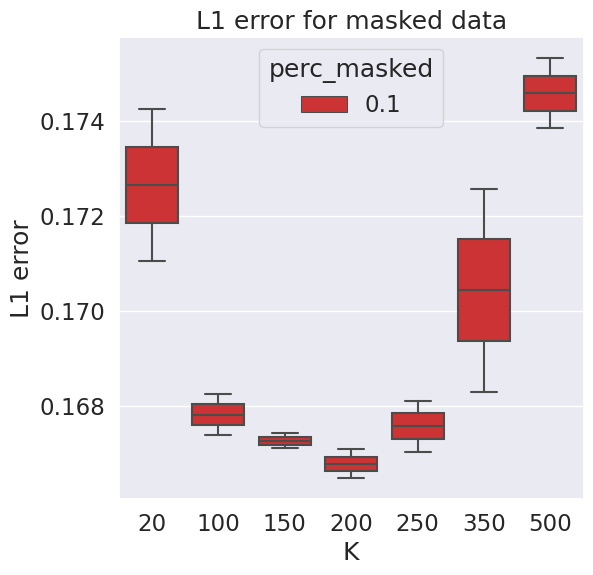

0.16647733278892796


In [16]:
# make boxplot of l1 error for each K and masking percentage
# sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(6, 6))

# use sns catplot to show K and perc masked
ax = sns.boxplot(x="K", y="l1", hue="perc_masked", data=masked_perf_df, palette="Set1")
ax.set_xlabel("K")
ax.set_ylabel("L1 error")
ax.set_title("L1 error for masked data")
plt.show()
print(masked_perf_df.l1.min())


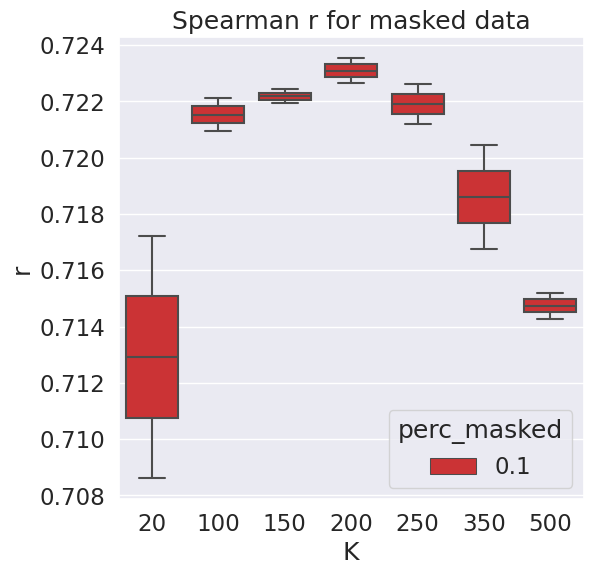

0.7235348836645721


In [17]:
# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(6, 6))

ax = sns.boxplot(x="K", y="r", hue="perc_masked", data=masked_perf_df, palette="Set1")
ax.set_xlabel("K")
ax.set_ylabel("r")
ax.set_title("Spearman r for masked data")
plt.show()
print(masked_perf_df.r.max())

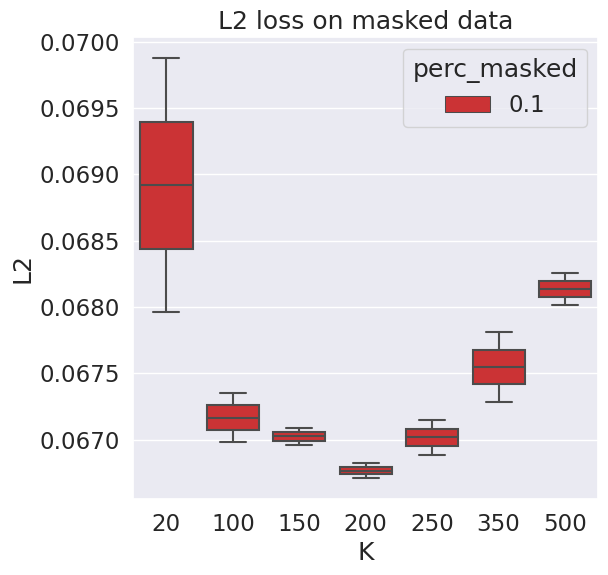

0.7235348836645721


In [18]:
# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(6, 6))

ax = sns.boxplot(x="K", y="l2", hue="perc_masked", data=masked_perf_df, palette="Set1")
ax.set_xlabel("K")
ax.set_ylabel("L2")
ax.set_title("L2 loss on masked data")
plt.show()
print(masked_perf_df.r.max())

In [19]:
# get median l1 error and pearson r for each K and across all masking percentages
median_l1 = masked_perf_df.groupby(["K"])["l1"].median()
median_r = masked_perf_df.groupby(["K"])["r"].median()
median_l2 = masked_perf_df.groupby(["K"])["l2"].median()

# find K that gives the lowest l1 error and print it
min_l1 = median_l1.idxmin()
print("The K that gives the lowest median l1 error is: " + str(min_l1))

# find K that gives the lowest l2 error and print it
min_l2 = median_l2.idxmin()
print("The K that gives the lowest median l2 error is: " + str(min_l2))

# find K that gives the highest r and print it
max_r = median_r.idxmax()
print("The K that gives the highest median r is: " + str(max_r))

The K that gives the lowest median l1 error is: 200
The K that gives the lowest median l2 error is: 200
The K that gives the highest median r is: 200


## Run full factor model! 

2.1.0.dev20230321+cu117
11.7
Tesla V100-PCIE-16GB
Using prior for a and b per junction to model average behaviour!
Initialization 1 with seed 3956
Define the guide
Fit the model
Epoch 0, Loss: 270447078.91961193
Epoch 10, Loss: 254539106.7144015
Epoch 20, Loss: 239798359.4452026
Epoch 30, Loss: 226691444.31673706
Epoch 40, Loss: 213999384.0580039
Epoch 50, Loss: 202586903.1989297
Epoch 60, Loss: 192228495.7120363
Epoch 70, Loss: 182296702.13432997
Epoch 80, Loss: 173227634.21644932
Epoch 90, Loss: 164868209.491361
Epoch 100, Loss: 156656375.41005617
Epoch 110, Loss: 148918955.43775982
Epoch 120, Loss: 141504548.57909924
Epoch 130, Loss: 134324014.99596506
Epoch 140, Loss: 127497729.18552032
Epoch 150, Loss: 120690469.46392694
Epoch 160, Loss: 114455451.67057501
Epoch 170, Loss: 108672607.61761817
Epoch 180, Loss: 103053573.53855506
Epoch 190, Loss: 98065325.89205837
Epoch 200, Loss: 93894202.75533813
Epoch 210, Loss: 90226209.18719748
Epoch 220, Loss: 86746553.21942154
Epoch 230, Loss:

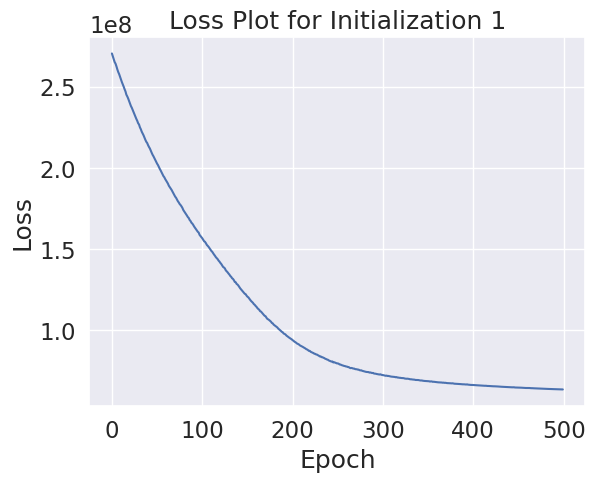

Sample from the guide (posterior)
Extract the latent variables
Initialization 2 with seed 3792
Define the guide
Fit the model
Epoch 0, Loss: 271745587.9549972
Epoch 10, Loss: 256156115.52268553
Epoch 20, Loss: 241620721.21730888
Epoch 30, Loss: 228050582.13466898
Epoch 40, Loss: 215645599.79003
Epoch 50, Loss: 204348826.03321677
Epoch 60, Loss: 194219581.9620242
Epoch 70, Loss: 184126681.83260354
Epoch 80, Loss: 175177973.5929806
Epoch 90, Loss: 166445910.65833277
Epoch 100, Loss: 158188907.40530547
Epoch 110, Loss: 150601688.26802164
Epoch 120, Loss: 143081549.60865274
Epoch 130, Loss: 135713145.70095715
Epoch 140, Loss: 128537103.65089253
Epoch 150, Loss: 121937860.18403661
Epoch 160, Loss: 115637377.05173644
Epoch 170, Loss: 109541260.45481789
Epoch 180, Loss: 104261805.07591704
Epoch 190, Loss: 99219420.3894896
Epoch 200, Loss: 94935459.31868505
Epoch 210, Loss: 90975316.05910893
Epoch 220, Loss: 87679127.30180246
Epoch 230, Loss: 84729229.84372468
Epoch 240, Loss: 82211499.0160760

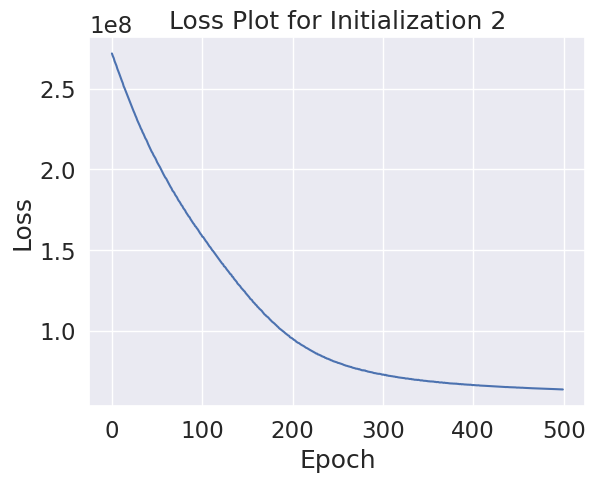

Sample from the guide (posterior)
Extract the latent variables
All initializations complete. Returning results.
------------------------------------------------


In [20]:
reload(factor_model)
best_K = 200 
K = best_K

all_results = factor_model.main(full_y_tensor, full_total_counts_tensor, num_initializations=2, use_global_prior=True, K=K, lr=0.01, loss_plot=True, num_epochs=500, save_to_file = False)

In [21]:
# extract latent variables for just first seed used 
latent_vars = all_results[1]['latent_vars'] 
pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k
conc = latent_vars["conc"] # one scaling value 

assign_post = latent_vars["assign"]

psis = latent_vars["psi"] # psi is the probability of a junction being used in a cluster

a = latent_vars["a"] 
b = latent_vars["b"] 
print(a)
print(b)

print("The inferred concentration parameter is: " + str(conc))
print("The inferred pi parameter is: " + str(pi))

[4.9858837 3.2206638 1.641742  ... 1.6430496 3.807766  2.910719 ]
[3.7162142 3.928317  1.919569  ... 4.428723  3.435694  4.1716976]
The inferred concentration parameter is: 26.92488
The inferred pi parameter is: [0.0076724  0.01628969 0.0056877  0.00565078 0.00596508 0.04606748
 0.00551952 0.01006544 0.00530209 0.00577617 0.00537175 0.00737153
 0.00577131 0.00562038 0.00873051 0.00620522 0.03379565 0.00548988
 0.00569833 0.00520996 0.00510225 0.00547262 0.01670314 0.00603515
 0.01524481 0.00593022 0.00493952 0.00679194 0.00601845 0.00686651
 0.00821634 0.01618224 0.00500061 0.00523688 0.00496267 0.01332781
 0.0109431  0.00570797 0.0045719  0.00451296 0.01036599 0.0044417
 0.00440626 0.00445877 0.00488458 0.00442819 0.00956976 0.00459818
 0.00438973 0.00934529 0.00449056 0.00631485 0.00414318 0.00559517
 0.00836712 0.00551557 0.00402887 0.00423204 0.00543939 0.00411429
 0.00406103 0.00465588 0.00426746 0.00705399 0.00581984 0.00383035
 0.00413315 0.00426066 0.00405886 0.00397831 0.00407

### Evaluate latent variables 

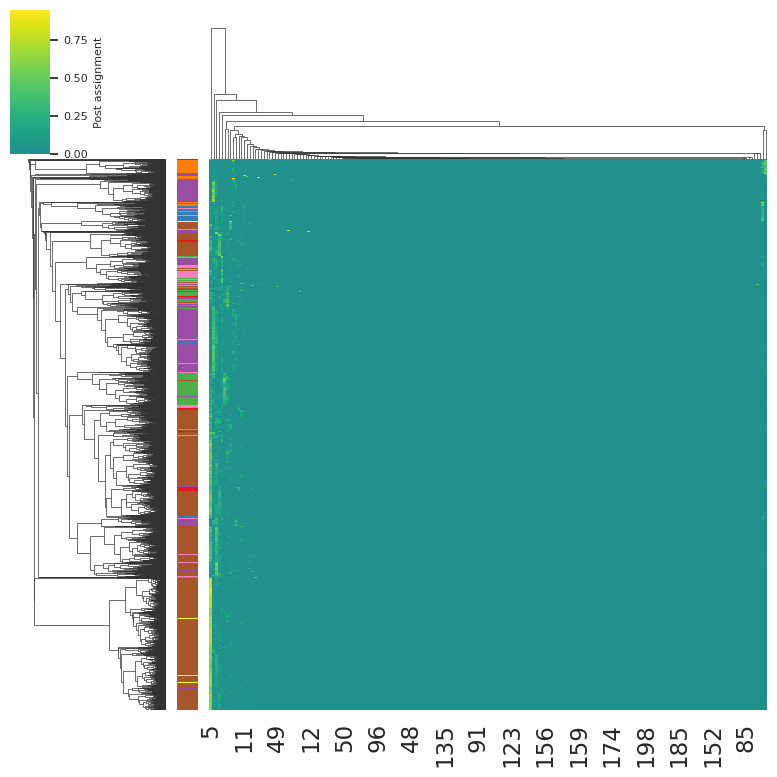

In [22]:
color_palette = sns.color_palette("Set1", n_colors=len(cell_ids_conversion['cell_type'].unique()))
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion['cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_ids_conversion.cell_type.values

# create colours for each cell type 
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

cluster = sns.clustermap(
    data=assign_post,
    method='complete',
    cmap="viridis",
    annot=False,
    fmt=".2f",
    yticklabels=False,
    figsize=(8, 8),
    center=0,
    row_colors=row_colors,  # Apply row colors
    cbar_kws={'label': 'Post assignment'} 
    )
cluster.cax.set_ylabel('Post assignment', size=8)
# Increase font size for color bar tick labels:
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(8)

In [23]:
# above heatmap is cluster assignment matrix 
# before heatmap we had one factor contributing to a bunch of cells 
# re-save those heatmaps for global prior and no global prior
# with PCA, you always have choice to center first or not, if not - but centering would have an effect, first PC ends up represnting the mean 
# for every gene, could have a PC where the values are always kind of constant for every cell 
# and the loading for the genes would just be their means... 
# can use a PC to model a mean 
# similarly here could just have a factor to represent the mean

The silhouette score for K = 200 is: 0.07287111
The Davies Bouldin score for K = 200 is: 2.1793107064676485


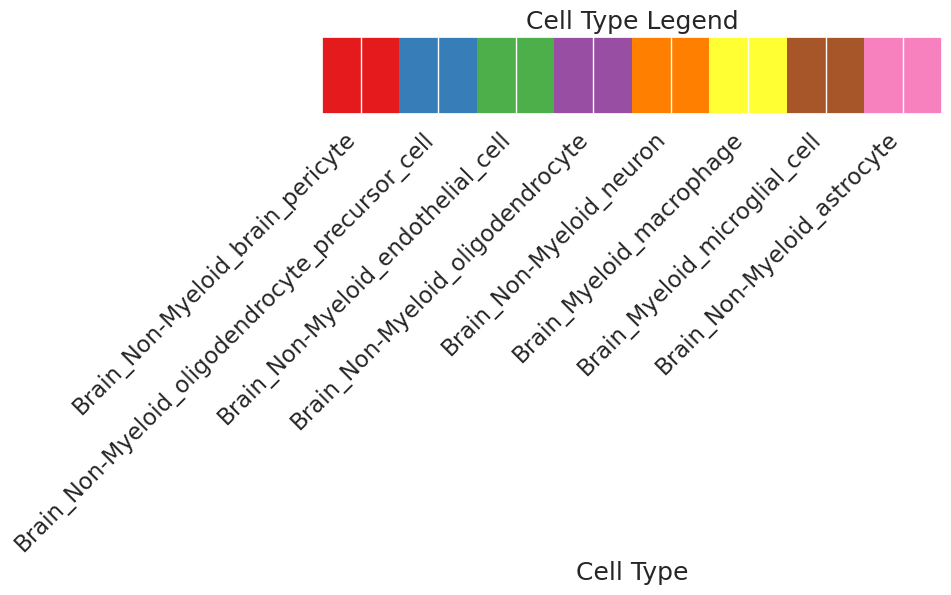

In [24]:
# print cell type color legend seperately
cell_type_colors
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)
sns.palplot(color_palette)
plt.title("Cell Type Legend")
# add cell type names to legend
plt.xticks(np.arange(len(unique_cell_types)), unique_cell_types, rotation=45, ha='right')
plt.xlabel("Cell Type")

# let's calculate silhouette score ussing assign_post
ss = silhouette_score(assign_post, cell_types)
# print with K equals K the ss is 
print("The silhouette score for K = " + str(K) + " is: " + str(ss))

# get davies bouldin score
from sklearn.metrics import davies_bouldin_score
dbs = davies_bouldin_score(assign_post, cell_types)
print("The Davies Bouldin score for K = " + str(K) + " is: " + str(dbs))

In [25]:
# make UMAP using average assign_post across seeds and color points by cell_type 
reducer = umap.UMAP()
embedding = reducer.fit_transform(assign_post)

/scratch/ipykernel_141527/908986799.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


Text(0, 0.5, 'UMAP 2')

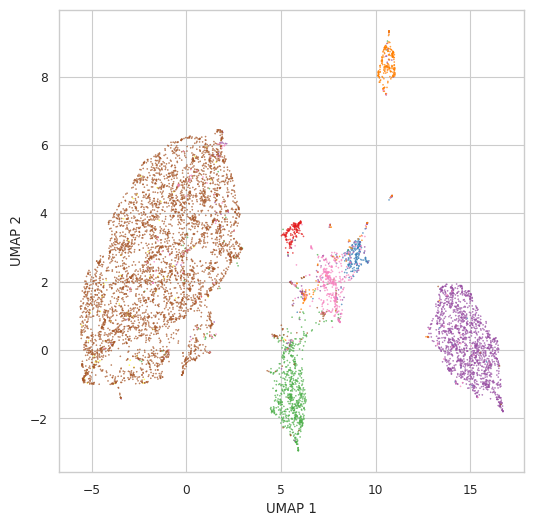

In [26]:
# plot UMAP 
# add whitegrid 
sns.set_style("whitegrid")
sns.set_context("paper")
plt.figure(figsize=(6, 6))
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[cell_type_colors[cell_type] for cell_type in cell_types],
    s=0.1,
    cmap="Spectral",
)
# xlab 
plt.xlabel("UMAP 1")
# ylab
plt.ylabel("UMAP 2")

([<matplotlib.axis.XTick at 0x7f61211e72b0>,
 [Text(0, 0, 'Brain_Non-Myeloid_brain_pericyte'),
  Text(1, 0, 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell'),
  Text(2, 0, 'Brain_Non-Myeloid_endothelial_cell'),
  Text(3, 0, 'Brain_Non-Myeloid_oligodendrocyte'),
  Text(4, 0, 'Brain_Non-Myeloid_neuron'),
  Text(5, 0, 'Brain_Myeloid_macrophage'),
  Text(6, 0, 'Brain_Myeloid_microglial_cell'),
  Text(7, 0, 'Brain_Non-Myeloid_astrocyte')])

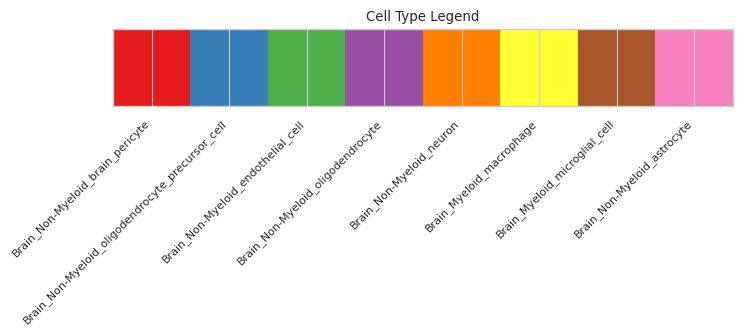

In [27]:
# plot cell_type_colors legend
sns.palplot(color_palette)
plt.title("Cell Type Legend")
# add cell type names to legend
plt.xticks(np.arange(len(unique_cell_types)), unique_cell_types, rotation=45, ha='right', size=8)

[0.458342   0.10441659 0.09063356 0.059196   0.05122156 0.04668055
 0.02537042 0.02413232 0.02337921 0.01701291]


/scratch/ipykernel_141527/2434076237.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


Text(0, 0.5, 'PC 2')

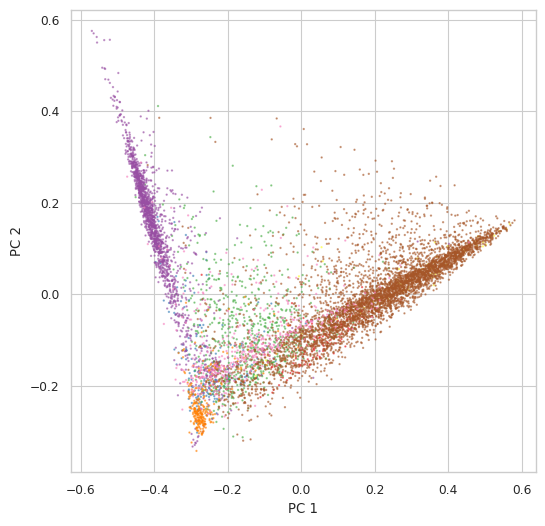

In [28]:
# now run PCA on assign_post 
pca = PCA(n_components=10)
pca.fit(assign_post)
print(pca.explained_variance_ratio_)

pcs = pca.transform(assign_post)
pcs_df = pd.DataFrame(pcs, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10"])
cell_types_pcs = cell_ids_conversion["cell_type"]

sns.set_style("whitegrid")
sns.set_context("paper")

plt.figure(figsize=(6, 6))
plt.scatter(
    pcs_df["PC1"],
    pcs_df["PC2"],
    c=[cell_type_colors[cell_type] for cell_type in cell_types],
    s=0.8, alpha=0.5, 
    cmap="Spectral",
)
# xlab 
plt.xlabel("PC 1")
# ylab
plt.ylabel("PC 2")

In [29]:
# for each cell type, get the average factor contribution
cell_type_contribs = {}
for cell_type in unique_cell_types:
    # get indices of cells of this cell type
    cell_type_indices = cell_ids_conversion[cell_ids_conversion["cell_type"] == cell_type].cell_id_index
    # get average factor contribution for these cells
    cell_type_contribs[cell_type] = assign_post[cell_type_indices].mean(axis=0)

# make a dataframe
cell_type_contribs_df = pd.DataFrame(cell_type_contribs)
cell_type_contribs_df = cell_type_contribs_df.T
cell_type_contribs_df.columns = ["Factor " + str(i) for i in range(K)]

cell_type_contribs_df


,Factor 0,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,...,Factor 190,Factor 191,Factor 192,Factor 193,Factor 194,Factor 195,Factor 196,Factor 197,Factor 198,Factor 199
Brain_Non-Myeloid_brain_pericyte,0.005846,0.009171,0.000386,0.000309,0.000655,0.322906,0.000234,0.094744,0.000239,0.000242,...,1.071194e-06,3.128841e-07,1.047506e-06,8.585505e-07,7.420085e-07,9.565493e-07,1.002662e-06,3.061103e-07,3.893302e-07,4.067060e-07
Brain_Non-Myeloid_oligodendrocyte_precursor_cell,0.000489,0.068650,0.000383,0.000345,0.000272,0.069303,0.000290,0.015891,0.000289,0.000387,...,6.453628e-07,5.698989e-07,1.339815e-06,4.944151e-07,1.020659e-06,1.974926e-07,1.934179e-07,2.450669e-07,2.745755e-07,1.728973e-07
Brain_Non-Myeloid_endothelial_cell,0.245675,0.111162,0.000463,0.000305,0.000578,0.164141,0.000314,0.183125,0.000205,0.000671,...,2.482862e-06,2.299697e-06,1.410165e-06,1.072512e-06,2.396227e-06,1.368471e-06,1.687349e-06,1.022617e-06,1.103838e-06,1.671331e-06
Brain_Non-Myeloid_oligodendrocyte,0.001472,0.339042,0.001128,0.000349,0.000935,0.014907,0.001605,0.005828,0.000427,0.000895,...,1.998851e-06,3.491184e-06,1.697015e-06,1.623809e-06,1.296671e-06,1.051576e-06,1.640536e-06,1.674630e-06,1.101399e-06,9.758769e-07
Brain_Non-Myeloid_neuron,0.000716,0.017607,0.002064,0.000350,0.000317,0.025796,0.000241,0.029351,0.000256,0.000279,...,1.467633e-06,1.841268e-06,1.282094e-06,1.114751e-06,1.019669e-06,8.380759e-07,1.601873e-06,1.032689e-06,8.136472e-07,5.872210e-07
Brain_Myeloid_macrophage,0.009680,0.016298,0.000438,0.000287,0.000429,0.593801,0.000189,0.041886,0.000165,0.000230,...,9.666229e-07,1.005175e-06,8.994352e-07,2.713035e-07,2.134234e-06,7.400014e-07,3.269898e-07,9.499049e-07,6.745865e-07,2.550703e-07
Brain_Myeloid_microglial_cell,0.005617,0.026378,0.000398,0.000313,0.000407,0.487014,0.000226,0.027597,0.000236,0.000424,...,1.370176e-06,1.101069e-06,1.515565e-06,1.057831e-06,2.030883e-06,1.066636e-06,6.207105e-07,9.411334e-07,5.647690e-07,5.396432e-07
Brain_Non-Myeloid_astrocyte,0.001732,0.046656,0.001736,0.000705,0.000444,0.167040,0.000398,0.014007,0.002847,0.000847,...,6.894049e-06,4.417312e-06,5.084713e-06,2.114555e-06,4.049054e-06,3.079922e-06,2.915754e-06,4.153870e-06,1.832974e-06,2.260209e-06


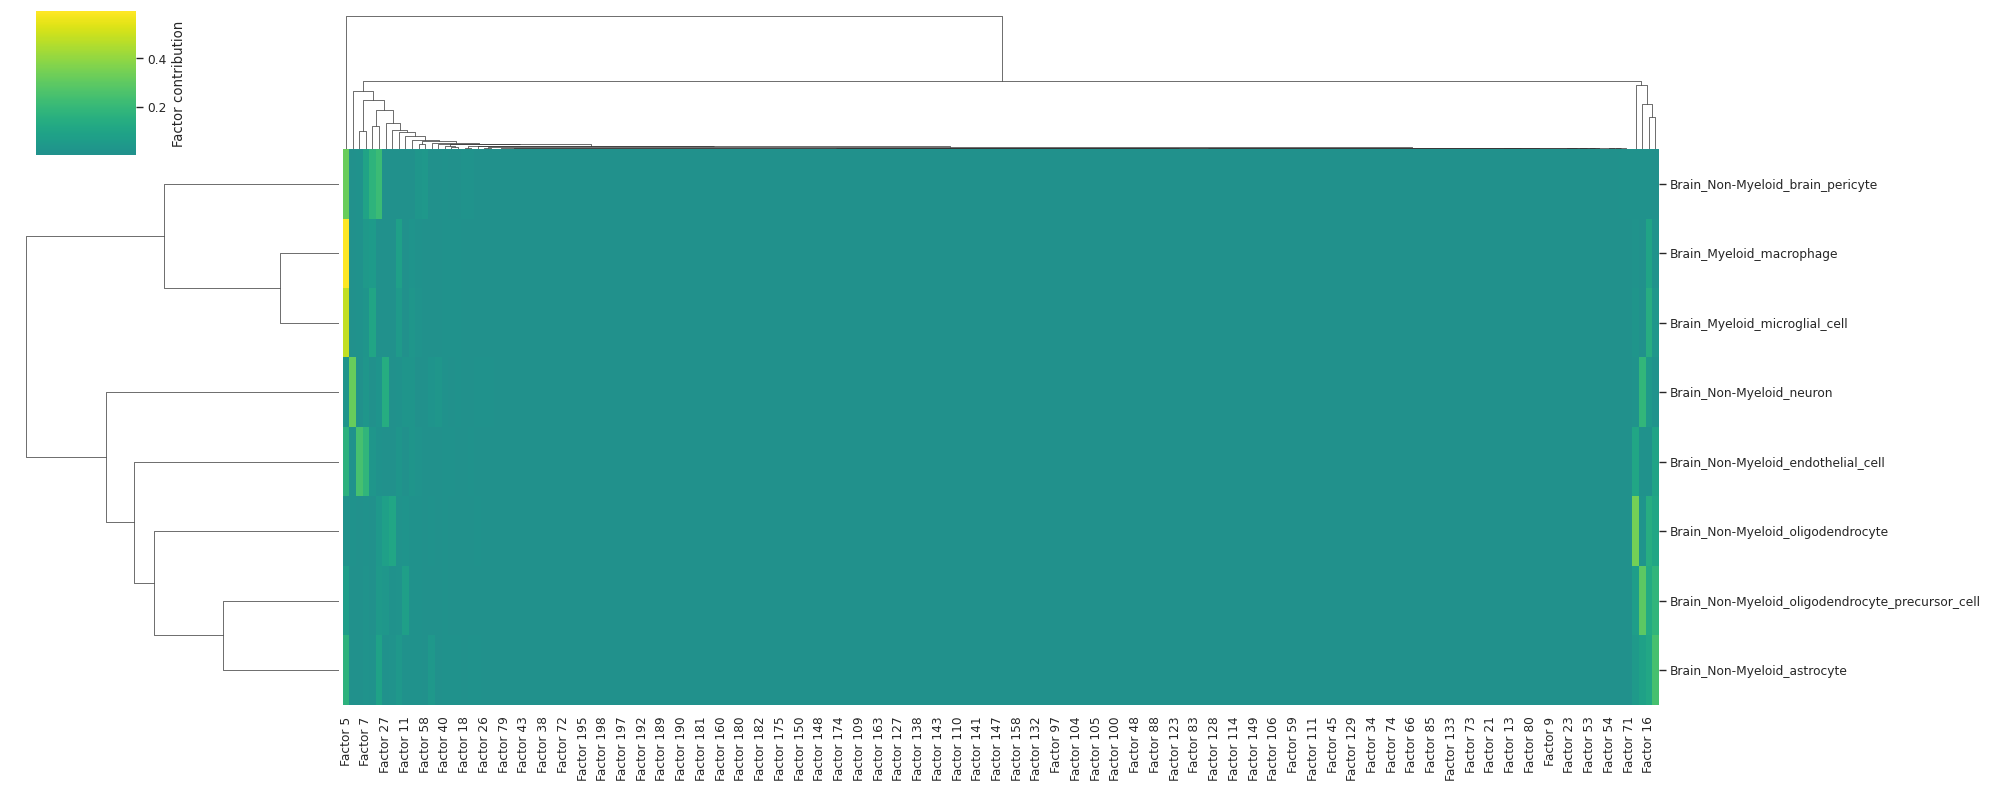

In [30]:
# plot clustermap 
sns.set_style("whitegrid")
sns.set_context("paper")
cluster = sns.clustermap(
    data=cell_type_contribs_df,
    method='complete',
    cmap="viridis",
    annot=False,
    # make font size smaller
    annot_kws={"size": 10},
    yticklabels=True,
    figsize=(20, 8),
    center=0,
    cbar_kws={'label': 'Factor contribution'} 
    )